In [1]:
import cv2
import tracking_methods
import numpy as np
import matplotlib.pyplot as plt
from tracking_methods import coarse_find, process_eye_crop, fit_ellipse, apply_smoothing, remove_bright_spots, find_dark_area, generate_ellipse_candidates, display_results


(np.float64(-0.5), np.float64(647.5), np.float64(367.5), np.float64(-0.5))

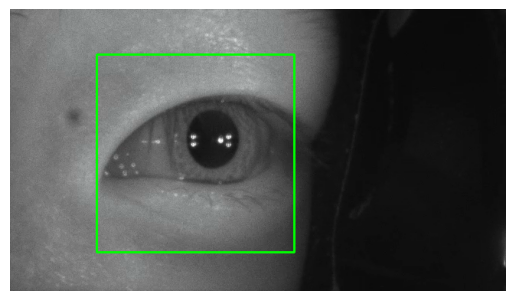

In [2]:
frame = cv2.imread("frames/16.png")
# show the image
eyes = coarse_find(frame, min_size=(200, 200))
eye_gray, x, y, size = process_eye_crop(frame, eyes)
cv2.rectangle(frame, (x, y), (x + size, y + size), (0, 255, 0), 2)
plt.imshow(frame)
plt.axis('off')  # Hide the axes
# get eye crop 



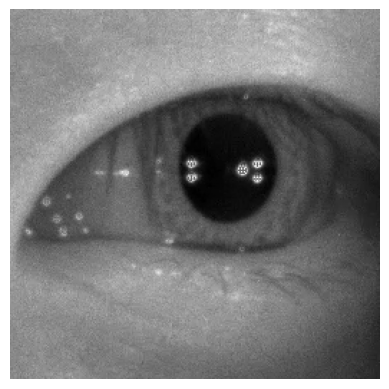

In [3]:

plt.axis('off') 
plt.imshow(eye_gray, cmap='gray')


Dark area value: 33.015306122448976


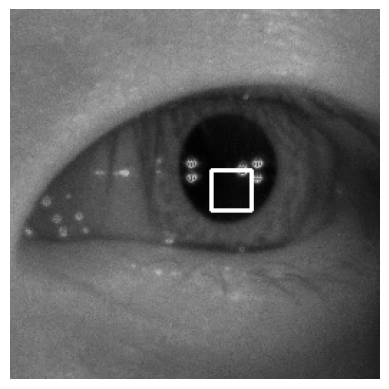

In [4]:
dark_square, dark_val = find_dark_area(eye_gray)
(y, x, h, w) = dark_square
cpy = eye_gray.copy()
cv2.rectangle(cpy, 
              (x, y), 
              (x + w, y + h), 
              (255, 0, 0), 2)
plt.imshow(cpy, cmap='gray')
plt.axis('off')  # Hide the axes
print(f"Dark area value: {dark_val}")


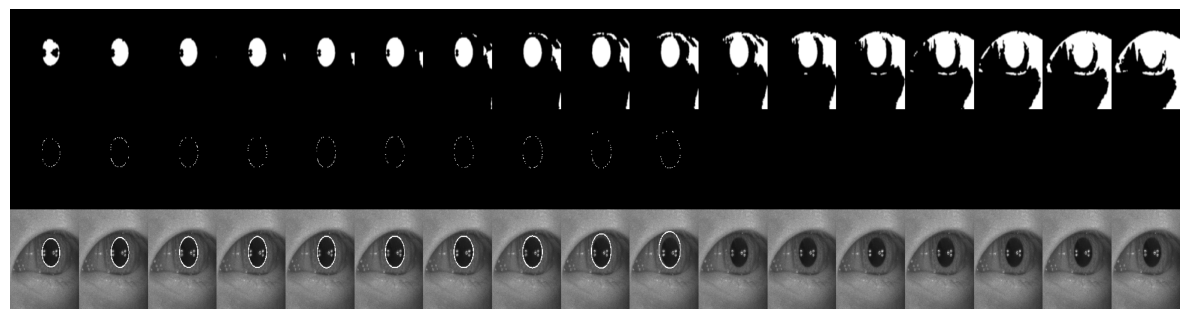

In [5]:
thresholds = [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48]

thresholded_images, contour_images, ellipse_images, ellipses = generate_ellipse_candidates(
    eye_gray, dark_val, thresholds
)

N = len(thresholded_images)
H, W = thresholded_images[0].shape
grid = np.zeros((3 * H, N * W), dtype=np.uint8)

for i in range(N):
    grid[0   :  H, i*W:(i+1)*W] = thresholded_images[i]
    grid[H   :2*H, i*W:(i+1)*W] = contour_images[i]
    grid[2*H :3*H, i*W:(i+1)*W] = ellipse_images[i]

# Resize for display
grid_disp = cv2.resize(grid, (2000, 512), interpolation=cv2.INTER_NEAREST)

# Display using matplotlib
plt.figure(figsize=(12, 6))
plt.imshow(grid_disp, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

((151.33258056640625, 109.5), (73.35933685302734, 82.17390441894531), 0.0)


(np.float64(-0.5), np.float64(257.5), np.float64(257.5), np.float64(-0.5))

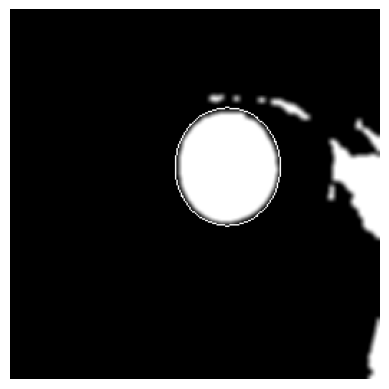

In [6]:
# plot 7th threshold
print(ellipses[7])
# unpack ellipse parameters
cv2.ellipse(thresholded_images[7],
            ellipses[7],
            (255, 255, ), 1)
plt.imshow(thresholded_images[7], cmap='gray')

plt.axis('off')


(np.float64(-0.5), np.float64(257.5), np.float64(257.5), np.float64(-0.5))

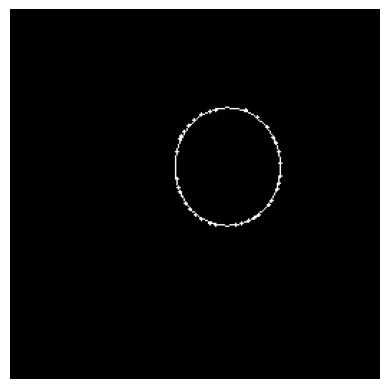

In [7]:

cv2.ellipse(contour_images[7],
            ellipses[7],
            (255, 255, ), 1)
plt.imshow(contour_images[7], cmap='gray')

plt.axis('off')

(np.float64(-0.5), np.float64(257.5), np.float64(257.5), np.float64(-0.5))

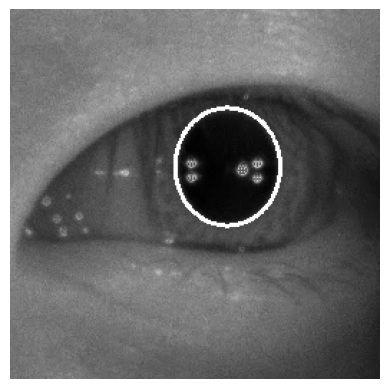

In [8]:

plt.imshow(ellipse_images[7], cmap='gray')

plt.axis('off')